### Simulating noisy quantum systems with Pauli propagation

In this tutorial we will use the ``pauli-prop`` package to classically simulate the time dynamics of a noisy 9-qubit transverse-field Ising model on a 3x3 square lattice. The Hamiltonian considered is:

$H = -J\sum\limits_{\langle i,j \rangle} Z_iZ_j + h\sum\limits_iX_i$

where $J>0$ describes the coupling of nearest-neighbor spins, $i<j$, and $h$ is the global transverse field. A second-order Trotter decomposition of the time-evolved operator will be implemented as a quantum circuit, $U$, over varying numbers of Trotter steps. We will estimate the expectation value of the average two-site correlator, $O = \langle Z_{tot}^2(s) \rangle = \frac{1}{N^2}\sum \langle \Psi(\theta)|(\mathscr{U}^{\dagger})^sZ_jZ_k(\mathscr{U})^s|\Psi(\theta) \rangle$, where $\Psi(\theta)$ is an initial excitation on all qubits and $\mathscr{U}^s$ describes $s$ Trotter layers, and $(j,k)$ index all pairs of vertices on the lattice.

Workflow:

### Generate a lattice and find a 4-coloring on the edges.

The coloring corresponds to the unique entangling layers of the quantum circuit representing the system.

In [1]:
import numpy as np
from collections import defaultdict
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.coloring import auto_color_edges

# Define rectangular square-lattice on 20 qubits
num_rows = 3
num_cols = 3
num_qubits = num_rows * num_cols

coupling_map = CouplingMap.from_grid(
    num_rows=num_rows, num_columns=num_cols, bidirectional=False
)

# Find the unique layers
coloring = auto_color_edges(coupling_map.get_edges())
color_to_edge = defaultdict(list)
for edge, color in coloring.items():
    color_to_edge[color].append(edge)

The circuit will have 9 qubits and 4 unique entangling layers.


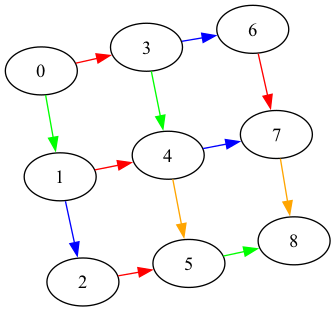

In [10]:
from rustworkx import PyDiGraph
from rustworkx.visualization import graphviz_draw

# Inspect graph coupling and unique entangling layers
print(f"The circuit will have {num_qubits} qubits and {len(color_to_edge)} unique entangling layers.")
sq_lattice = PyDiGraph()
sq_lattice.extend_from_weighted_edge_list(
    [(source, target, color) for ((source, target), color) in coloring.items()]
)


def color_edge_4color(edge):
    color_dict = {0: "red", 1: "green", 2: "blue", 3: "orange"}
    return {"color": color_dict[edge]}


graphviz_draw(sq_lattice, edge_attr_fn=color_edge_4color, method="neato")

### Generate circuits of up to 6 Trott

This system has been shown to have interesting time dynamics, and larger problem instances have proven to be challenging for Pauli propagation techniques to accurately simulate [$\textcolor{red}{cite-quantinuum}$].

In [3]:
from typing import Any
from qiskit import QuantumCircuit
from qiskit_aer.noise import PauliLindbladError
from qiskit.quantum_info import pauli_basis, SparsePauliOp

def generate_random_pauli_lindblad_noise(
    edges,
    num_qubits: int | None = None,
    noise_scale: float = 1e-3,
    seed: int | None = None,
) -> PauliLindbladError:
    if num_qubits == None:
        num_qubits = np.max(edges)

    basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
    basis_paulis = SparsePauliOp.from_sparse_list(
        [(pauli.to_label(), edge, 1) for pauli in basis_paulis for edge in edges],
        num_qubits=num_qubits,
    )
    basis_paulis = (
        basis_paulis.simplify()
    )  # remove duplicates (multiple edges may have same pauli)
    basis_paulis = basis_paulis.paulis

    rng = np.random.default_rng(seed=seed)
    rates = rng.random(len(basis_paulis)) * noise_scale

    return PauliLindbladError(generators=basis_paulis, rates=rates)

def generate_2d_ising_circuit(
    num_qubits: int,
    num_steps: int,
    rx_angle: float,
    rz_angle: float,
    coloring: dict[Any, list[tuple[int, int]]],
    layer_noise_models: list[PauliLindbladError] | None = None,
    initial_state_angle: float | None = None,
) -> QuantumCircuit:
    # Create noisy quantum circuit
    qc = QuantumCircuit(num_qubits)
    if initial_state_angle:
        qc.ry(initial_state_angle, range(num_qubits))
    qc.rx(rx_angle / 2, range(num_qubits))
    for i in range(num_steps):
        for i, layer in enumerate(coloring):
            edges = coloring[layer]
            for edge in edges:
                qc.cx(*edge)
            if layer_noise_models:
                qc.append(layer_noise_models[i], qargs=range(num_qubits))
            for edge in edges:
                qc.rz(rz_angle, edge[1])
            for edge in edges:
                qc.cx(*edge)
            if layer_noise_models:
                qc.append(layer_noise_models[i], qargs=range(num_qubits))
        if i == num_steps - 1:
            qc.rx(rx_angle / 2, range(num_qubits))
        else:
            qc.rx(rx_angle, range(num_qubits))

    return qc

# Pauli-Lindblad noise parameters
seed = 1764
target_EPLGs = [.0001, .0005, .001, .002]
num_generators = (
    (num_rows * num_cols) + (num_rows - 1) * num_cols + num_rows * (num_cols - 1)
)
noise_scales = [EPLG * (num_rows * num_cols) / num_generators for EPLG in target_EPLGs]
noise_models_per_EPLG = [[generate_random_pauli_lindblad_noise(coupling_map.get_edges(), num_qubits=num_qubits, noise_scale=noise_scale, seed=seed) for _ in range(len(color_to_edge))] for noise_scale in noise_scales]

# Ising model parameters
max_num_steps = 7
J = -1.0
dt = 0.25 / abs(J)
h = 2.0 * abs(J)
initial_state_angle = np.pi / 18.0
rx_angle = 2.0 * h * dt
rz_angle = 2.0 * J * dt

noiseless_circs = []
noisy_circs = []
for steps in range(max_num_steps):
    # Create the circuit
    noiseless_circs.append(generate_2d_ising_circuit(num_qubits, steps, rx_angle, rz_angle, color_to_edge, initial_state_angle=initial_state_angle))
    noisy_circs_per_step = []
    for i, noise_models in enumerate(noise_models_per_EPLG):
        noisy_circs_per_step.append(generate_2d_ising_circuit(num_qubits, steps, rx_angle, rz_angle, color_to_edge, layer_noise_models=noise_models, initial_state_angle=initial_state_angle))
    noisy_circs.append(noisy_circs_per_step)

In [4]:
from qiskit.quantum_info import Pauli
from pauli_prop import evolve_through_cliffords, propagate_through_circuit

max_terms = 4 ** num_qubits # Exact propagation
id_pauli = Pauli("I" * num_qubits)
observable = 2 * SparsePauliOp(
    [
        id_pauli.dot(Pauli("ZZ"), [i, j])
        for i in range(num_qubits)
        for j in range(i + 1, num_qubits)
    ]
)
observable /= num_qubits**2

exact_evs = []
noisy_evs = [[] for _ in range(len(target_EPLGs))]
for i, noiseless_circ in enumerate(noiseless_circs):
    cliff, non_cliff = evolve_through_cliffords(noiseless_circ)
    evolved_obs = propagate_through_circuit(
        observable, non_cliff, max_terms=max_terms, atol=1e-12, frame="h"
    )[0]
    evolved_obs.paulis = evolved_obs.paulis.evolve(cliff, frame="h")
    exact_evs.append(float(evolved_obs.coeffs[~evolved_obs.paulis.x.any(axis=1)].sum()))
    for j in range(len(target_EPLGs)):
        noisy_circ = noisy_circs[i][j]
        cliff, non_cliff = evolve_through_cliffords(noisy_circ)
        evolved_obs = propagate_through_circuit(
            observable, non_cliff, max_terms=max_terms, atol=1e-12, frame="h"
        )[0]
        evolved_obs.paulis = evolved_obs.paulis.evolve(cliff, frame="h")
        noisy_evs[j].append(float(evolved_obs.coeffs[~evolved_obs.paulis.x.any(axis=1)].sum()))